# Proyecto completo en Google Colab: ChatBot sencillo con Transformer (TensorFlow/Keras) entrenado desde un .txt

> **Objetivo didáctico**: construir, entrenar y probar un ChatBot *pequeño pero real* basado en Transformer (Encoder–Decoder), usando **TensorFlow (Keras)** y un dataset cargado desde un **archivo `.txt`** con el formato:
>
> **PREGUNTA ||| RESPUESTA**
>
> Este cuaderno está pensado para estudiantes que ya programan en Python y conocen ML supervisado / redes simples, pero ven Transformers por primera vez.

## 1. Introducción

### 1.1 Qué problema resuelve un ChatBot

Un ChatBot, en su versión más simple, busca resolver un problema de **mapeo de texto a texto**:

- **Entrada**: una frase del usuario (pregunta).
- **Salida**: una frase de respuesta (respuesta “adecuada” según ejemplos vistos).

En términos de aprendizaje supervisado, estamos aprendiendo una función:

**f(pregunta) → respuesta**

No estamos “razonando” como un humano; estamos aprendiendo patrones estadísticos de cómo responder **según un conjunto de ejemplos**.

### 1.2 Por qué RNN/LSTM no son ideales

RNNs y LSTMs fueron muy usadas para secuencias, pero tienen límites conocidos:

- Procesan la secuencia **paso a paso** (no paralelizan tan bien).
- Les cuesta capturar dependencias largas (aunque LSTM mejora esto, no lo elimina).
- En práctica, entrenar y escalar modelos secuenciales puede ser más lento y frágil.

### 1.3 Por qué los Transformers son el estándar actual

Los Transformers cambiaron el juego porque:

- Usan **atención** (attention) para “mirar” todas las palabras relevantes a la vez.
- Se entrenan de forma **altamente paralelizable**.
- Escalan muy bien: con más datos y cómputo, mejoran de forma notable (base conceptual detrás de GPT, T5, etc.).

En este notebook haremos un Transformer pequeño, **educativo**, no un LLM.

## 2. Conceptos fundamentales del Transformer

### 2.1 Tokenización

Un modelo no entiende texto directamente. Necesita **tokens** (unidades), por ejemplo:

- Tokenización por palabras (más simple, pero vocabulario grande).
- Tokenización subword (BPE/WordPiece; más robusta, pero más compleja).

Aquí usaremos una tokenización sencilla con `TextVectorization` de Keras (orientada a aprendizaje).

### 2.2 Embeddings

Los tokens (IDs enteros) se convierten en vectores densos con una capa `Embedding`.

**Idea**: en vez de representar palabras como “números arbitrarios”, las representamos como vectores donde el modelo puede aprender similitudes.

### 2.3 Positional Encoding

La atención por sí sola no sabe el orden de las palabras.

Por eso se agrega información de posición:

- “Este token estaba en la posición 0”
- “Este token estaba en la posición 1”, etc.

Implementaremos **positional encoding sinusoidal** manualmente para ver la lógica.

### 2.4 Self-Attention

Self-attention responde:  
**“¿A qué otras palabras de la misma oración debería prestar atención esta palabra?”**

Ejemplo (intuitivo): en “El gato que viste ayer…”, la palabra “viste” podría atender a “gato”, “ayer”, etc.

### 2.5 Multi-Head Attention

No queremos una sola “forma de atender”.  
Multi-head attention usa varias “cabezas” para aprender distintos patrones de relación (sintaxis, referencias, énfasis, etc.).

### 2.6 Encoder y Decoder

- **Encoder**: lee la entrada (pregunta) y produce una representación contextual.
- **Decoder**: genera la salida (respuesta) **token por token**, atendiendo:
  1) a lo ya generado (self-attention en decoder)  
  2) a la información del encoder (cross-attention)

### 2.7 Flujo general de datos

1) Pregunta → tokens → embeddings + posiciones → **Encoder** → “memoria”  
2) Respuesta (desplazada) → tokens → embeddings + posiciones → **Decoder** + memoria → predicción del siguiente token  
3) Entrenamiento: comparamos predicción vs token real siguiente.

## 3. Explicación detallada de los datos de entrenamiento

### 3.1 Por qué usar pares pregunta–respuesta

Porque queremos supervisión directa:  
**“si entra X, debería salir Y”**.

Esto hace que el proyecto sea claro y fácil de evaluar.

### 3.2 Ventajas de usar un archivo de texto

- Fácil de editar.
- Fácil de compartir con estudiantes.
- Permite que el dataset se adapte a un tema (por ejemplo: IA, universidad, reglamento de clase, etc.).

### 3.3 Formato `PREGUNTA ||| RESPUESTA`

Cada línea debe tener exactamente un separador:

```
PREGUNTA ||| RESPUESTA
```

Reglas obligatorias:
- Una pregunta y una respuesta por línea.
- No líneas vacías.
- UTF-8 y español.
- Respuestas concisas y consistentes.

### 3.4 Dataset educativo vs producción

- **Educativo**: pequeño, controlado, con respuestas cortas y “limpias”. Sirve para entender.
- **Producción**: requiere muchísimos datos, diversidad lingüística, manejo de errores, seguridad, sesgos, etc.

### 3.5 Tamaño recomendado para pruebas educativas

Para que Colab entrene rápido y el código sea comprensible:

- **Mínimo**: 200–500 pares (para ver aprendizaje básico).
- **Mejor**: 1,000–5,000 pares (mejor generalización, aún manejable).
- Si hay menos de 100 pares, el modelo tenderá a memorizar y responder mal fuera del set.

## 4. Cargue del archivo de texto en Google Colab

### (Código) Subir archivo con `files.upload()` y leerlo

In [1]:
# ============================================================
# SECCIÓN 4: CARGA DEL ARCHIVO .TXT EN GOOGLE COLAB
# ============================================================
# En Colab, una forma sencilla de cargar archivos locales es:
#   from google.colab import files
#   uploaded = files.upload()
#
# Esto abre un selector para que el estudiante suba entrenamiento.txt
#
# Luego leemos el archivo en modo texto y lo procesamos línea por línea.
# ============================================================

from google.colab import files
import io

uploaded = files.upload()  # El usuario debe subir un .txt (por ejemplo entrenamiento.txt)

# Tomamos el primer archivo subido (en un curso, normalmente se sube uno solo)
filename = list(uploaded.keys())[0]
raw_text = uploaded[filename].decode("utf-8")

print("Archivo cargado:", filename)
print("Primeros 500 caracteres del archivo:\n")
print(raw_text[:500])

Saving entrenamiento_constitucion.txt to entrenamiento_constitucion.txt
Archivo cargado: entrenamiento_constitucion.txt
Primeros 500 caracteres del archivo:

¿En qué año se promulgó la Constitución de Colombia? ||| La Constitución Política de Colombia se promulgó en 1991.
¿Qué es la Constitución de 1991? ||| Es la ley fundamental de la República de Colombia, también conocida como la Carta Magna.
¿Cuál es el apodo de la Constitución de 1991? ||| Se le conoce como la "Constitución de los Derechos Humanos".
¿Qué es una acción de tutela? ||| Es un mecanismo para proteger los derechos constitucionales fundamentales de los ciudadanos de manera inmediata.
¿


### (Código) Parseo robusto del formato `PREGUNTA ||| RESPUESTA`

In [2]:
# ============================================================
# SECCIÓN 4 (continuación): PARSEO DEL DATASET
# ============================================================
# Vamos a transformar el texto del archivo en dos listas:
#   preguntas: [str, str, ...]
#   respuestas: [str, str, ...]
#
# Además, agregamos validaciones educativas:
# - No permitir líneas vacías
# - Exigir exactamente un separador "|||"
# - Exigir que pregunta y respuesta no queden vacías
# ============================================================

def parse_qa_txt(raw_text, separator="|||"):
    preguntas = []
    respuestas = []

    lines = raw_text.splitlines()

    # Validación: no permitir archivo vacío
    if len(lines) == 0:
        raise ValueError("El archivo está vacío. Debe contener líneas con 'PREGUNTA ||| RESPUESTA'.")

    for idx, line in enumerate(lines, start=1):
        # Quitamos espacios extremos
        line = line.strip()

        # Regla: no líneas vacías
        if line == "":
            raise ValueError(f"Línea {idx} está vacía. El archivo no debe tener líneas vacías.")

        # Regla: el separador es obligatorio
        if separator not in line:
            raise ValueError(f"Línea {idx} no contiene el separador '{separator}'. Línea: {line}")

        # Regla: exactamente 2 partes (pregunta y respuesta)
        parts = line.split(separator)
        if len(parts) != 2:
            raise ValueError(
                f"Línea {idx} tiene {len(parts)} partes al separar por '{separator}'. Deben ser exactamente 2."
            )

        q = parts[0].strip()
        a = parts[1].strip()

        if q == "" or a == "":
            raise ValueError(f"Línea {idx} tiene pregunta o respuesta vacía. Línea: {line}")

        preguntas.append(q)
        respuestas.append(a)

    return preguntas, respuestas

preguntas, respuestas = parse_qa_txt(raw_text)

print("Número de pares pregunta-respuesta:", len(preguntas))
print("\nEjemplos:")
for i in range(min(3, len(preguntas))):
    print(f"- Q: {preguntas[i]}")
    print(f"  A: {respuestas[i]}")

Número de pares pregunta-respuesta: 470

Ejemplos:
- Q: ¿En qué año se promulgó la Constitución de Colombia?
  A: La Constitución Política de Colombia se promulgó en 1991.
- Q: ¿Qué es la Constitución de 1991?
  A: Es la ley fundamental de la República de Colombia, también conocida como la Carta Magna.
- Q: ¿Cuál es el apodo de la Constitución de 1991?
  A: Se le conoce como la "Constitución de los Derechos Humanos".


## 5. Preprocesamiento de los datos

### 5.1 Por qué preprocesar

El Transformer necesita tensores numéricos:

- Texto → tokens → IDs
- Longitudes variables → padding a longitud fija (o por batch)

También agregaremos tokens especiales para el decoder:
- `<start>` al inicio de la respuesta
- `<end>` al final

Esto ayuda al modelo a saber:
- dónde empieza a generar
- cuándo debe detenerse en inferencia

### 5.2 Limpieza básica del texto (sin complicarlo)

No haremos normalización agresiva. Solo:
- pasar a minúsculas
- separar puntuación básica (opcional)
- quitar espacios dobles

Esto es suficiente para un proyecto educativo.

### (Código) Limpieza y construcción de textos para encoder/decoder

In [3]:
# ============================================================
# SECCIÓN 5: PREPROCESAMIENTO DE TEXTO
# ============================================================
# Mantendremos una limpieza simple para no "ocultar" el aprendizaje.
# En producción, se suele cuidar mucho más (acentos, signos, emojis, etc.).
# ============================================================

import re

def basic_clean_text(s: str) -> str:
    # 1) minúsculas
    s = s.lower().strip()

    # 2) espacios múltiples -> uno
    s = re.sub(r"\s+", " ", s)

    # 3) (Opcional educativo) separar algunos signos de puntuación
    #    Esto ayuda a que "hola?" y "hola" no queden pegados.
    s = re.sub(r"([?.!,¿¡])", r" \1 ", s)
    s = re.sub(r"\s+", " ", s).strip()

    return s

preguntas_clean = [basic_clean_text(q) for q in preguntas]
respuestas_clean = [basic_clean_text(a) for a in respuestas]

# Agregamos tokens especiales en respuestas:
START_TOKEN = "<start>"
END_TOKEN = "<end>"

respuestas_in = [f"{START_TOKEN} {a}" for a in respuestas_clean]   # input al decoder
respuestas_out = [f"{a} {END_TOKEN}" for a in respuestas_clean]     # objetivo (target)

print("Ejemplo limpio:")
print("Q:", preguntas_clean[0])
print("Decoder IN:", respuestas_in[0])
print("Decoder OUT:", respuestas_out[0])

Ejemplo limpio:
Q: ¿ en qué año se promulgó la constitución de colombia ?
Decoder IN: <start> la constitución política de colombia se promulgó en 1991 .
Decoder OUT: la constitución política de colombia se promulgó en 1991 . <end>


### 5.3 Tokenización, vocabulario y secuencias numéricas

Usaremos `TextVectorization` para:

- crear vocabulario
- mapear texto → secuencia de IDs
- padding/truncation a una longitud fija

**Ojo didáctico importante**:  
Aquí crearemos **dos vectorizadores**:
- uno para el encoder (preguntas)
- uno para el decoder (respuestas con `<start>/<end>`)

Esto mantiene el razonamiento claro.

### (Código) Crear vectorizadores

In [4]:
# ============================================================
# SECCIÓN 5: TOKENIZACIÓN Y VECTORIZACIÓN (Keras)
# ============================================================
# TextVectorization:
# - aprende un vocabulario a partir de textos
# - convierte texto en secuencias de enteros
# - puede hacer padding a una longitud fija (output_sequence_length)
#
# Importante:
# - Vamos a fijar longitudes máximas. En un dataset educativo, las frases
#   deberían ser relativamente cortas.
# ============================================================

import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

# Hiperparámetros educativos
MAX_VOCAB_SIZE = 5000          # vocabulario máximo
ENC_SEQ_LEN = 20               # longitud máxima para preguntas
DEC_SEQ_LEN = 20               # longitud máxima para respuestas

# Vectorizador para preguntas (encoder)
enc_vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=ENC_SEQ_LEN,
    standardize=None,  # ya limpiamos nosotros
)

# Vectorizador para respuestas (decoder)
dec_vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=DEC_SEQ_LEN,
    standardize=None,
)

# "Adaptar" = construir vocabulario
enc_vectorizer.adapt(preguntas_clean)
dec_vectorizer.adapt(respuestas_in + respuestas_out)

# Vocabularios (listas de strings)
enc_vocab = enc_vectorizer.get_vocabulary()
dec_vocab = dec_vectorizer.get_vocabulary()

print("Tamaño vocab encoder:", len(enc_vocab))
print("Tamaño vocab decoder:", len(dec_vocab))
print("\nEjemplo vocab decoder (primeros 20):", dec_vocab[:20])

Tamaño vocab encoder: 498
Tamaño vocab decoder: 1010

Ejemplo vocab decoder (primeros 20): ['', '[UNK]', np.str_('.'), np.str_('es'), np.str_('la'), np.str_('de'), np.str_('el'), np.str_('<start>'), np.str_('<end>'), np.str_('a'), np.str_('y'), np.str_('del'), np.str_('los'), np.str_('que'), np.str_('derecho'), np.str_('en'), np.str_('por'), np.str_('las'), np.str_('estado'), np.str_('para')]


### 5.4 Convertir a tensores y explicar shapes

Vamos a construir:
- `encoder_input`: (N, ENC_SEQ_LEN)
- `decoder_input`: (N, DEC_SEQ_LEN)
- `decoder_target`: (N, DEC_SEQ_LEN)

Donde:
- N = número de pares en el dataset

### (Código) Construcción de dataset TensorFlow

In [5]:
# ============================================================
# SECCIÓN 5: CREAR DATASET (tf.data)
# ============================================================
# Para entrenar en Keras, lo ideal es usar tf.data.Dataset
# - eficiente
# - claro
# - permite batch, shuffle, prefetch
#
# Aquí el modelo recibirá:
#   inputs = (encoder_input, decoder_input)
#   target = decoder_target
# ============================================================

import numpy as np

# Convertimos texto -> secuencias de enteros
encoder_input = enc_vectorizer(tf.constant(preguntas_clean)).numpy()
decoder_input = dec_vectorizer(tf.constant(respuestas_in)).numpy()
decoder_target = dec_vectorizer(tf.constant(respuestas_out)).numpy()

print("Shapes:")
print("encoder_input:", encoder_input.shape)     # (N, ENC_SEQ_LEN)
print("decoder_input:", decoder_input.shape)     # (N, DEC_SEQ_LEN)
print("decoder_target:", decoder_target.shape)   # (N, DEC_SEQ_LEN)

# Creamos tf.data.Dataset
BATCH_SIZE = 32
BUFFER_SIZE = len(encoder_input)

ds = tf.data.Dataset.from_tensor_slices(((encoder_input, decoder_input), decoder_target))
ds = ds.shuffle(BUFFER_SIZE, reshuffle_each_iteration=True).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Separación simple train/val (educativa)
VAL_FRACTION = 0.1
val_size = int(np.ceil((len(encoder_input) * VAL_FRACTION) / BATCH_SIZE))

val_ds = ds.take(val_size)
train_ds = ds.skip(val_size)

print("Batches train:", tf.data.experimental.cardinality(train_ds).numpy())
print("Batches val:", tf.data.experimental.cardinality(val_ds).numpy())

Shapes:
encoder_input: (470, 20)
decoder_input: (470, 20)
decoder_target: (470, 20)
Batches train: 13
Batches val: 2


## 6. Implementación del Transformer paso a paso (TensorFlow)

### 6.1 Filosofía de implementación (sin ocultar la lógica)

En Keras existen capas listas para atención, pero aquí el requisito es **no ocultar la lógica interna**.

Aun así, seremos realistas: implementaremos:
- Positional Encoding manual
- Scaled Dot-Product Attention manual
- Multi-Head Attention manual (con Dense y reshape)
- Bloques Encoder/Decoder manuales

**Meta educativa**: que el estudiante *vea* el flujo.

---

### 6.2 Positional Encoding (sinusoidal) manual

**Por qué**: el embedding no tiene orden; esto añade “posición” como señal.

### (Código) Positional Encoding

In [6]:
# ============================================================
# SECCIÓN 6.2: POSITIONAL ENCODING (SINUSOIDAL)
# ============================================================
# La idea clave:
# - Tenemos embeddings de tamaño D (d_model)
# - Para cada posición pos (0..seq_len-1) generamos un vector de tamaño D
# - Usamos sin/cos en distintas frecuencias
#
# Esto permite que el modelo "deduzca" relaciones de posición.
# ============================================================

import tensorflow as tf
import numpy as np

def positional_encoding(seq_len, d_model):
    """
    Retorna una matriz (seq_len, d_model) con el positional encoding.
    """
    # posiciones: (seq_len, 1)
    positions = np.arange(seq_len)[:, np.newaxis]

    # índices de dimensiones: (1, d_model)
    dims = np.arange(d_model)[np.newaxis, :]

    # Fórmula clásica: angle_rates = 1 / (10000^(2i/d_model))
    angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
    angles = positions * angle_rates

    # Aplicamos sin a índices pares, cos a impares
    pe = np.zeros_like(angles)
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])

    return tf.cast(pe, tf.float32)

# Prueba rápida
test_pe = positional_encoding(seq_len=5, d_model=8)
print("Forma posicional encoding:", test_pe.shape)
print(test_pe.numpy())

Forma posicional encoding: (5, 8)
[[ 0.0000000e+00  1.0000000e+00  0.0000000e+00  1.0000000e+00
   0.0000000e+00  1.0000000e+00  0.0000000e+00  1.0000000e+00]
 [ 8.4147096e-01  5.4030228e-01  9.9833414e-02  9.9500418e-01
   9.9998331e-03  9.9994999e-01  9.9999981e-04  9.9999952e-01]
 [ 9.0929741e-01 -4.1614684e-01  1.9866933e-01  9.8006660e-01
   1.9998666e-02  9.9980003e-01  1.9999987e-03  9.9999797e-01]
 [ 1.4112000e-01 -9.8999250e-01  2.9552022e-01  9.5533651e-01
   2.9995501e-02  9.9955004e-01  2.9999956e-03  9.9999553e-01]
 [-7.5680250e-01 -6.5364361e-01  3.8941833e-01  9.2106098e-01
   3.9989334e-02  9.9920011e-01  3.9999895e-03  9.9999201e-01]]


---

### 6.3 Scaled Dot-Product Attention (manual)

**Por qué “scaled”**: sin escalar, el producto punto crece con la dimensión y el softmax se vuelve inestable.

### (Código) Atención básica

In [7]:
# ============================================================
# SECCIÓN 6.3: SCALED DOT-PRODUCT ATTENTION
# ============================================================
# Entrada:
#   Q: (batch, heads, seq_q, depth)
#   K: (batch, heads, seq_k, depth)
#   V: (batch, heads, seq_k, depth)
#   mask: (batch, 1, 1, seq_k) o (batch, 1, seq_q, seq_k) según el caso
#
# Salida:
#   output: (batch, heads, seq_q, depth)
#   attention_weights: (batch, heads, seq_q, seq_k)
# ============================================================

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Implementación manual de atención.
    """
    # scores = QK^T / sqrt(depth)
    matmul_qk = tf.matmul(Q, K, transpose_b=True)
    depth = tf.cast(tf.shape(K)[-1], tf.float32)
    scores = matmul_qk / tf.math.sqrt(depth)

    # Si hay máscara, ponemos valores muy negativos donde NO se debe atender
    if mask is not None:
        scores += (mask * -1e9)

    # softmax sobre la dimensión seq_k
    attention_weights = tf.nn.softmax(scores, axis=-1)

    # combinación ponderada de V
    output = tf.matmul(attention_weights, V)
    return output, attention_weights

---

### 6.4 Multi-Head Attention (manual)

**Por qué múltiples cabezas**: diferentes proyecciones capturan diferentes relaciones.

### (Código) Multi-Head Attention

In [8]:
# ============================================================
# SECCIÓN 6.4: MULTI-HEAD ATTENTION (MANUAL)
# ============================================================
# Vamos a construir una capa Keras personalizada.
# - Proyecta inputs a Q, K, V con Dense
# - Divide en 'num_heads'
# - Aplica scaled_dot_product_attention
# - Concatena cabezas y proyecta a d_model
# ============================================================

from tensorflow.keras import layers

class MultiHeadAttention(layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.depth = d_model // num_heads

        # Proyecciones lineales para Q, K, V
        self.wq = layers.Dense(d_model)
        self.wk = layers.Dense(d_model)
        self.wv = layers.Dense(d_model)

        # Proyección final
        self.dense = layers.Dense(d_model)

    def split_heads(self, x):
        """
        Convierte (batch, seq_len, d_model) a (batch, heads, seq_len, depth)
        """
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]

        x = tf.reshape(x, (batch_size, seq_len, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, q, k, v, mask=None):
        # Proyección a d_model
        Q = self.wq(q)
        K = self.wk(k)
        V = self.wv(v)

        # Separar cabezas
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # Atención
        attention_output, attention_weights = scaled_dot_product_attention(Q, K, V, mask)

        # Volver a (batch, seq_len, d_model)
        attention_output = tf.transpose(attention_output, perm=[0, 2, 1, 3])
        batch_size = tf.shape(attention_output)[0]
        seq_len = tf.shape(attention_output)[1]

        concat_attention = tf.reshape(attention_output, (batch_size, seq_len, self.d_model))

        # Proyección final
        output = self.dense(concat_attention)
        return output, attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
        })
        return config

---

### 6.5 Feed-Forward Network (FFN) del Transformer

**Por qué**: después de mezclar información con atención, el modelo necesita transformar representaciones de manera no lineal.

### (Código) FFN

In [9]:
# ============================================================
# SECCIÓN 6.5: FEED-FORWARD NETWORK
# ============================================================
# Estructura típica:
#   Dense(d_ff, activation='relu') -> Dense(d_model)
# ============================================================

def point_wise_feed_forward_network(d_model, d_ff):
    return tf.keras.Sequential([
        layers.Dense(d_ff, activation="relu"),
        layers.Dense(d_model),
    ])

---

### 6.6 Encoder Layer y Encoder

Incluye:
- Self-attention
- Residual connection + LayerNorm
- FFN
- Residual connection + LayerNorm
- Dropout

### (Código) Encoder

In [10]:
# ============================================================
# SECCIÓN 6.6: ENCODER (CAPA Y PILA)
# ============================================================
# EncoderLayer:
#   x -> MHA(self) -> add+norm -> FFN -> add+norm
#
# Encoder:
#   tokens -> embedding -> + positional encoding -> dropout
#   -> N capas EncoderLayer
# ============================================================

class EncoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = point_wise_feed_forward_network(d_model, d_ff)

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, x, training=False, mask=None):
        # 1) Self-attention: q=k=v=x
        attn_output, _ = self.mha(x, x, x, mask)
        attn_output = self.dropout1(attn_output, training=training)

        # Residual + norm
        out1 = self.layernorm1(x + attn_output)

        # 2) FFN
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)

        # Residual + norm
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.mha.d_model, # Access d_model from mha or store directly
            "num_heads": self.mha.num_heads,
            "d_ff": self.ffn.layers[0].units, # Assuming d_ff is the first dense layer's units
            "dropout_rate": self.dropout1.rate, # Access rate from dropout layer
        })
        return config


class Encoder(layers.Layer):
    def __init__(self, vocab_size, seq_len, num_layers, d_model, num_heads, d_ff, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.seq_len = seq_len
        self.num_layers = num_layers
        self.vocab_size = vocab_size # Store vocab_size
        self.num_heads = num_heads # Store num_heads
        self.d_ff = d_ff # Store d_ff
        self.dropout_rate = dropout_rate # Store dropout_rate

        self.embedding = layers.Embedding(vocab_size, d_model)
        self.dropout = layers.Dropout(dropout_rate)

        self.enc_layers = [
            EncoderLayer(d_model, num_heads, d_ff, dropout_rate)
            for _ in range(num_layers)
        ]

        # Precalculamos positional encoding para la longitud máxima
        self.pos_encoding = positional_encoding(seq_len, d_model)

    def call(self, x, training=False, mask=None):
        # x: (batch, seq_len)
        seq_len = tf.shape(x)[1]

        # Embedding: (batch, seq_len, d_model)
        x = self.embedding(x)

        # Escalamiento típico: embeddings * sqrt(d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))

        # Sumamos positional encoding (recortado a seq_len real)
        x += self.pos_encoding[:seq_len, :]

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)

        return x  # (batch, seq_len, d_model)

    def get_config(self):
        config = super().get_config()
        config.update({
            "vocab_size": self.vocab_size,
            "seq_len": self.seq_len,
            "num_layers": self.num_layers,
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "d_ff": self.d_ff,
            "dropout_rate": self.dropout_rate,
        })
        return config

---

### 6.7 Máscaras: padding y look-ahead

**Por qué**:

1) **Padding mask**: no queremos atender a ceros de padding.  
2) **Look-ahead mask** (en decoder): al predecir el token t, no podemos “ver” tokens futuros.

### (Código) Máscaras

In [11]:
# ============================================================
# SECCIÓN 6.7: MÁSCARAS
# ============================================================
# Padding mask:
# - Identifica posiciones donde token==0 (Keras TextVectorization usa 0 para padding).
# - Luego se usa para anular atención hacia esas posiciones.
#
# Look-ahead mask:
# - Matriz triangular superior (para bloquear el futuro).
# ============================================================

def create_padding_mask(seq):
    """
    seq: (batch, seq_len)
    Retorna: (batch, 1, 1, seq_len)
    con 1 en posiciones a enmascarar.
    """
    mask = tf.cast(tf.math.equal(seq, 0), tf.float32)
    return mask[:, tf.newaxis, tf.newaxis, :]  # broadcasting

def create_look_ahead_mask(size):
    """
    size: int (seq_len)
    Retorna: (size, size) con 1 arriba de la diagonal
    """
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask  # (seq_len, seq_len)

def create_decoder_masks(decoder_seq):
    """
    Combina:
    - look ahead (futuro)
    - padding (en la misma salida)
    Retorna máscara lista para atención: (batch, 1, seq_len, seq_len)
    """
    seq_len = tf.shape(decoder_seq)[1]
    look_ahead = create_look_ahead_mask(seq_len)  # (seq_len, seq_len)
    padding = tf.cast(tf.math.equal(decoder_seq, 0), tf.float32)  # (batch, seq_len)

    # Expandimos padding para poder combinarlo con look-ahead
    padding = padding[:, tf.newaxis, tf.newaxis, :]  # (batch,1,1,seq_len)
    look_ahead = look_ahead[tf.newaxis, tf.newaxis, :, :]  # (1,1,seq_len,seq_len)

    return tf.maximum(look_ahead, padding)

---

### 6.8 Decoder Layer y Decoder

En cada DecoderLayer hay:

1) **Masked self-attention** (no ver futuro)  
2) **Cross-attention** (attend a la salida del encoder)  
3) **FFN**

### (Código) Decoder

In [12]:
# ============================================================
# SECCIÓN 6.8: DECODER (CAPA Y PILA)
# ============================================================
# DecoderLayer:
#   x -> MHA(masked self) -> add+norm
#     -> MHA(cross: q=x, k=v=enc_out) -> add+norm
#     -> FFN -> add+norm
#
# Decoder:
#   tokens -> embedding -> + positional encoding -> dropout
#   -> N capas DecoderLayer
# ============================================================

class DecoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)

        self.mha1 = MultiHeadAttention(d_model, num_heads)  # self-attention
        self.mha2 = MultiHeadAttention(d_model, num_heads)  # cross-attention

        self.ffn = point_wise_feed_forward_network(d_model, d_ff)

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)
        self.dropout3 = layers.Dropout(dropout_rate)

    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        # 1) Masked self-attention
        attn1, _ = self.mha1(x, x, x, look_ahead_mask)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(x + attn1)

        # 2) Cross-attention (q=out1, k=v=enc_output)
        attn2, _ = self.mha2(out1, enc_output, enc_output, padding_mask)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(out1 + attn2)

        # 3) FFN
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.layernorm3(out2 + ffn_output)

        return out3

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.mha1.d_model,
            "num_heads": self.mha1.num_heads,
            "d_ff": self.ffn.layers[0].units,
            "dropout_rate": self.dropout1.rate,
        })
        return config


class Decoder(layers.Layer):
    def __init__(self, vocab_size, seq_len, num_layers, d_model, num_heads, d_ff, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.seq_len = seq_len
        self.num_layers = num_layers
        self.vocab_size = vocab_size # Store vocab_size
        self.num_heads = num_heads # Store num_heads
        self.d_ff = d_ff # Store d_ff
        self.dropout_rate = dropout_rate # Store dropout_rate

        self.embedding = layers.Embedding(vocab_size, d_model)
        self.dropout = layers.Dropout(dropout_rate)

        self.dec_layers = [
            DecoderLayer(d_model, num_heads, d_ff, dropout_rate)
            for _ in range(num_layers)
        ]

        self.pos_encoding = positional_encoding(seq_len, d_model)

    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        # x: (batch, seq_len)
        seq_len = tf.shape(x)[1]

        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:seq_len, :]
        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.dec_layers[i](
                x, enc_output, training=training,
                look_ahead_mask=look_ahead_mask,
                padding_mask=padding_mask
            )

        return x  # (batch, seq_len, d_model)

    def get_config(self):
        config = super().get_config()
        config.update({
            "vocab_size": self.vocab_size,
            "seq_len": self.seq_len,
            "num_layers": self.num_layers,
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "d_ff": self.d_ff,
            "dropout_rate": self.dropout_rate,
        })
        return config

---

### 6.9 Transformer completo

- Encoder
- Decoder
- Capa final `Dense(vocab_size_decoder)` para logits

### (Código) Modelo completo

In [13]:
# ============================================================
# SECCIÓN 6.9: TRANSFORMER COMPLETO (Keras Model)
# ============================================================
# Entradas:
#   encoder_input: (batch, ENC_SEQ_LEN)
#   decoder_input: (batch, DEC_SEQ_LEN)
#
# Salida:
#   logits: (batch, DEC_SEQ_LEN, vocab_decoder)
#
# Nota:
# - Usamos vocab del decoder para predecir tokens de la respuesta.
# ============================================================

class Transformer(tf.keras.Model):
    def __init__(self, enc_vocab_size, dec_vocab_size,
                 enc_seq_len, dec_seq_len,
                 num_layers=2, d_model=128, num_heads=4, d_ff=256, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)

        self.enc_vocab_size = enc_vocab_size
        self.dec_vocab_size = dec_vocab_size
        self.enc_seq_len = enc_seq_len
        self.dec_seq_len = dec_seq_len
        self.num_layers = num_layers
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_ff = d_ff
        self.dropout_rate = dropout_rate

        self.encoder = Encoder(enc_vocab_size, enc_seq_len, num_layers, d_model, num_heads, d_ff, dropout_rate)
        self.decoder = Decoder(dec_vocab_size, dec_seq_len, num_layers, d_model, num_heads, d_ff, dropout_rate)

        self.final_layer = layers.Dense(dec_vocab_size)

    def call(self, inputs, training=False):
        encoder_input, decoder_input = inputs

        # Máscaras
        enc_padding_mask = create_padding_mask(encoder_input)
        dec_look_ahead_mask = create_decoder_masks(decoder_input)
        # En cross-attention, queremos enmascarar padding del encoder
        dec_padding_mask = enc_padding_mask

        # Encoder
        enc_output = self.encoder(encoder_input, training=training, mask=enc_padding_mask)

        # Decoder
        dec_output = self.decoder(
            decoder_input, enc_output, training=training,
            look_ahead_mask=dec_look_ahead_mask,
            padding_mask=dec_padding_mask
        )

        # Logits finales
        logits = self.final_layer(dec_output)
        return logits

    def get_config(self):
        config = super().get_config()
        config.update({
            "enc_vocab_size": self.enc_vocab_size,
            "dec_vocab_size": self.dec_vocab_size,
            "enc_seq_len": self.enc_seq_len,
            "dec_seq_len": self.dec_seq_len,
            "num_layers": self.num_layers,
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "d_ff": self.d_ff,
            "dropout_rate": self.dropout_rate,
        })
        return config

    @classmethod
    def from_config(cls, config):
        # Extract the arguments needed for the __init__ method
        enc_vocab_size = config.pop("enc_vocab_size")
        dec_vocab_size = config.pop("dec_vocab_size")
        enc_seq_len = config.pop("enc_seq_len")
        dec_seq_len = config.pop("dec_seq_len")
        num_layers = config.pop("num_layers")
        d_model = config.pop("d_model")
        num_heads = config.pop("num_heads")
        d_ff = config.pop("d_ff")
        dropout_rate = config.pop("dropout_rate")

        # The remaining items in 'config' are for the base Model class's __init__
        return cls(
            enc_vocab_size=enc_vocab_size,
            dec_vocab_size=dec_vocab_size,
            enc_seq_len=enc_seq_len,
            dec_seq_len=dec_seq_len,
            num_layers=num_layers,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout_rate=dropout_rate,
            **config  # Pass remaining config (e.g., name, trainable) to super().__init__
        )


## 7. Compilación y entrenamiento del modelo

### 7.1 Función de pérdida

Como el decoder predice un token por posición, usamos **SparseCategoricalCrossentropy**.

Pero debemos ignorar el padding (token 0), porque no queremos “aprender a predecir padding”.

### 7.2 Optimizador

Usaremos Adam con un learning rate fijo (educativo).  
En papers, Transformers usan schedules más sofisticados, pero aquí priorizamos claridad.

### 7.3 Métrica

Usaremos accuracy **en tokens no-padding** (aproximación).  
Ojo: alta accuracy no siempre significa buenas respuestas (porque es token-level).

### (Código) Loss y entrenamiento

In [14]:
# ============================================================
# SECCIÓN 7: COMPILACIÓN Y ENTRENAMIENTO
# ============================================================
# Vamos a:
# - Instanciar un Transformer pequeño
# - Definir una loss que ignore padding (token 0)
# - Compilar y entrenar con train_ds y val_ds
# ============================================================

# Hiperparámetros del modelo (pequeño, educativo)
NUM_LAYERS = 2
D_MODEL = 128
NUM_HEADS = 4
D_FF = 256
DROPOUT = 0.1

transformer = Transformer(
    enc_vocab_size=len(enc_vocab),
    dec_vocab_size=len(dec_vocab),
    enc_seq_len=ENC_SEQ_LEN,
    dec_seq_len=DEC_SEQ_LEN,
    num_layers=NUM_LAYERS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    dropout_rate=DROPOUT
)

loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")

def masked_loss(y_true, y_pred):
    """
    y_true: (batch, dec_seq_len)
    y_pred: (batch, dec_seq_len, vocab)

    Calculamos loss por token, y luego ignoramos donde y_true==0 (padding).
    """
    y_true = tf.cast(y_true, tf.int32) # Cast y_true to int32 for type consistency
    loss_ = loss_object(y_true, y_pred)  # (batch, dec_seq_len)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)  # 1 para tokens reales
    loss_ *= mask
    return tf.reduce_sum(loss_) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    """
    Accuracy token-level ignorando padding.
    """
    y_pred_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
    y_true = tf.cast(y_true, tf.int32) # Cast y_true to int32 for type consistency
    matches = tf.cast(tf.equal(y_true, y_pred_ids), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    matches *= mask
    return tf.reduce_sum(matches) / tf.reduce_sum(mask)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

transformer.compile(optimizer=optimizer, loss=masked_loss, metrics=[masked_accuracy])

# Entrenamiento: pocas épocas para Colab + demo educativa
EPOCHS = 50

history = transformer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 29s 404ms/step - loss: 6.2782 - masked_accuracy: 0.0768 - val_loss: 5.0433 - val_masked_accuracy: 0.2801
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - loss: 4.8398 - masked_accuracy: 0.2960 - val_loss: 4.3839 - val_masked_accuracy: 0.3059
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - loss: 4.2912 - masked_accuracy: 0.3248 - val_loss: 3.7604 - val_masked_accuracy: 0.3861
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - loss: 3.8802 - masked_accuracy: 0.3617 - val_loss: 3.5386 - val_masked_accuracy: 0.3969
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - loss: 3.5414 - masked_accuracy: 0.3895 - val_loss: 3.3546 - val_masked_accuracy: 0.3934
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - loss: 3.2134 - masked_accuracy: 0.4294 - val_loss: 2.9672 - val_masked_accuracy: 0.4381
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - loss: 2.9771 - masked_accuracy: 0.4507 - val_loss: 2.6299 - val_masked_accuracy: 0.5096
Epoch

### 7.4 Comentarios sobre overfitting y underfitting (sin matemáticas)

- **Underfitting**: el modelo no aprende ni los patrones básicos. Señales:
  - loss alta en train y val
  - respuestas incoherentes incluso a preguntas del dataset

- **Overfitting**: memoriza el dataset y generaliza mal. Señales:
  - train loss baja, val loss alta
  - responde bien a preguntas vistas, mal a similares nuevas

En un dataset pequeño, el overfitting es común. Aquí es aceptable como fenómeno didáctico.

## 8. Prueba del ChatBot

### 8.1 Idea de inferencia (por qué es diferente a entrenamiento)

En entrenamiento, el decoder recibe la respuesta “correcta” desplazada (`<start> ...`) y aprende a predecir el siguiente token.

En inferencia, **no tenemos la respuesta**. Entonces:

1) damos la pregunta al encoder  
2) iniciamos el decoder con `<start>`  
3) predecimos el siguiente token  
4) lo añadimos a la secuencia  
5) repetimos hasta `<end>` o longitud máxima

Esto se llama **decoding autoregresivo**.

### 8.2 Necesitamos convertir tokens ↔ texto

- Del usuario: texto → secuencia con `enc_vectorizer`
- Predicción: IDs → palabras con `dec_vocab`

### (Código) Funciones de ayuda para inferencia

In [15]:
# ============================================================
# SECCIÓN 8: INFERENCIA (CHATBOT)
# ============================================================
# Vamos a implementar greedy decoding:
# - En cada paso elegimos el token con mayor probabilidad (argmax).
# Esto NO es lo más "inteligente", pero sí lo más claro para aprender.
# ============================================================

# Mapear id -> token (string) para el decoder
id_to_token = {i: t for i, t in enumerate(dec_vocab)}

# Encontrar el id del token <start> y <end> en el vocab del decoder
# Nota: si el token no aparece, es que algo falló en el preprocesamiento.
start_id = dec_vectorizer(tf.constant([START_TOKEN])).numpy()[0][0]
end_id = dec_vectorizer(tf.constant([END_TOKEN])).numpy()[0][0]

print("start_id:", start_id, "token:", id_to_token.get(int(start_id), None))
print("end_id:", end_id, "token:", id_to_token.get(int(end_id), None))

def encode_question(question: str):
    """
    Limpia y vectoriza una pregunta del usuario.
    Retorna tensor shape (1, ENC_SEQ_LEN)
    """
    q = basic_clean_text(question)
    enc = enc_vectorizer(tf.constant([q]))
    return enc

def greedy_decode(transformer, question: str, max_len=DEC_SEQ_LEN):
    """
    Genera respuesta token por token usando greedy decoding.
    """
    # 1) Preparar encoder input
    enc_in = encode_question(question)  # (1, ENC_SEQ_LEN)

    # 2) Inicializar decoder input con <start>
    output_ids = [int(start_id)]

    for _ in range(max_len - 1):
        # Construimos el decoder input con padding hasta DEC_SEQ_LEN
        dec_in = output_ids + [0] * (DEC_SEQ_LEN - len(output_ids))
        dec_in = tf.constant([dec_in], dtype=tf.int32)  # (1, DEC_SEQ_LEN)

        # 3) Forward pass
        logits = transformer((enc_in, dec_in), training=False)  # (1, DEC_SEQ_LEN, vocab)

        # 4) Tomamos el paso actual (len(output_ids)-1)
        step = len(output_ids) - 1
        step_logits = logits[:, step, :]  # (1, vocab)

        next_id = int(tf.argmax(step_logits, axis=-1).numpy()[0])

        # 5) Si predice <end>, paramos
        if next_id == int(end_id):
            break

        output_ids.append(next_id)

    # Convertimos ids a tokens (ignorando <start>)
    tokens = [id_to_token.get(i, "") for i in output_ids[1:]]
    # Unimos tokens con espacios y limpiamos un poco
    text = " ".join(tokens).replace("  ", " ").strip()
    return text

start_id: 7 token: <start>
end_id: 8 token: <end>


### 8.3 Chat por consola (bucle interactivo)

In [16]:
# ============================================================
# SECCIÓN 8.3: BUCLE DE CHAT POR CONSOLA
# ============================================================
# En Colab, input() funciona. El estudiante puede escribir preguntas.
# Escriba "salir" para terminar.
# ============================================================

while True:
    user_text = input("\nTú: ").strip()
    if user_text.lower() in ["salir", "exit", "quit"]:
        print("ChatBot: ¡Hasta luego!")
        break

    bot_text = greedy_decode(transformer, user_text)
    print("ChatBot:", bot_text)


Tú: ¿En qué año se promulgó la Constitución de Colombia?
ChatBot: la constitución política de colombia se promulgó en 1991 .

Tú: ¿Qué es el Consejo de Estado?
ChatBot: es el máximo tribunal de lo contencioso administrativo .

Tú: quit
ChatBot: ¡Hasta luego!


### 8.4 Explicación: cómo el Decoder genera token por token

Conceptualmente:

- El decoder mantiene una secuencia parcial: `<start> ...`
- En cada paso:
  - produce logits para todas las posiciones
  - nos interesa la posición actual
  - elegimos el token más probable
  - lo anexamos y repetimos

Esto es el núcleo de la generación autoregresiva.

## 9. Limitaciones del modelo

### 9.1 Tamaño del dataset

Con pocos pares:
- el modelo memoriza (overfitting)
- responde con frases genéricas o repetitivas
- no generaliza a variaciones (“hola”, “holaa”, “buenas”)

### 9.2 Dominio limitado

El bot solo responde “bien” dentro de su mundo: lo que vio en entrenamiento.

### 9.3 Capacidad del modelo

Un Transformer pequeño:
- tiene pocos parámetros
- no aprende conocimiento amplio
- no es comparable a modelos preentrenados

### 9.4 Comparación conceptual con GPT

GPT-like:
- entrenado con enormes corpus
- tokenización subword robusta
- arquitecturas grandes y optimizadas
- técnicas de alineamiento, safety, RLHF, etc.

Aquí:
- dataset pequeño
- entrenamiento desde cero
- propósito pedagógico

## 10. Cómo llevar este proyecto a producción

### 10.1 Mejorar y expandir el dataset

- Más pares, más diversidad de formas de preguntar
- Validación de consistencia de respuestas
- Cobertura de sinónimos y errores ortográficos

### 10.2 Fine-tuning

En vez de entrenar desde cero:
- tomar un modelo preentrenado (ej. T5 pequeño)
- ajustarlo a tu dominio con pocos datos

### 10.3 Uso de modelos preentrenados

Para producción real, casi siempre conviene:
- modelos encoder-decoder preentrenados
- o LLMs via API

### 10.4 Exponer mediante API (Flask/FastAPI)

- Endpoint `/chat`
- Recibe JSON `{ "text": "..." }`
- Responde JSON `{ "reply": "..." }`

### 10.5 Rendimiento

- batching de inferencia (si hay muchos usuarios)
- quantization o modelos más pequeños
- caching de respuestas frecuentes
- monitoreo de calidad (logs, feedback)

# Apéndice: Recomendación de un archivo entrenamiento.txt (ejemplo pequeño)

> **Importante**: este ejemplo es muy pequeño. Sirve para probar el pipeline, no para calidad real.

```
hola ||| hola, ¿en qué puedo ayudarte?
¿qué es un transformer? ||| es una arquitectura basada en mecanismos de atención.
¿qué es inteligencia artificial? ||| es un área que busca construir sistemas capaces de realizar tareas inteligentes.
¿qué es aprendizaje supervisado? ||| es un enfoque donde entrenamos con ejemplos de entrada y salida correcta.
gracias ||| con gusto, ¿quieres preguntar algo más?
```

---

In [17]:
!pip install nltk

In [18]:
# ============================================================
# CÓDIGO PARA CALCULAR MÉTRICAS
# ============================================================
from nltk.translate.bleu_score import corpus_bleu
import numpy as np

# Mapear id -> token (string) para el decoder
id_to_token = {i: t for i, t in enumerate(dec_vocab)}
# Necesitamos el ID del token de padding para ignorarlo
padding_id = dec_vectorizer([""]).numpy()[0][0]

def ids_to_text(ids):
    """Convierte una secuencia de IDs a texto, ignorando padding y tokens especiales."""
    tokens = []
    for i in ids:
        token = id_to_token.get(i, "")
        if i != padding_id and token not in [START_TOKEN, END_TOKEN]:
            tokens.append(token)
    return " ".join(tokens)

def evaluate_model_bleu(model, dataset):
    """
    Calcula la puntuación BLEU para un dataset completo.

    Args:
        model: El modelo Transformer entrenado.
        dataset: El tf.data.Dataset de validación (o prueba).

    Returns:
        La puntuación BLEU del corpus.
    """
    all_references = []
    all_hypotheses = []

    # Iteramos sobre el dataset de validación
    for (encoder_input, decoder_input), y_true in dataset:

        # Generamos la respuesta del modelo token por token (hipótesis)
        # Para esto, necesitamos iterar sobre cada ejemplo del batch
        for i in range(encoder_input.shape[0]):
            enc_in_single = encoder_input[i:i+1] # Mantener la dimensión del batch

            # Convertimos la pregunta (ID) a texto para la función de decoding
            question_text = ids_to_text(enc_in_single.numpy()[0])

            # Generamos la respuesta
            hypothesis_text = greedy_decode(model, question_text)

            # Obtenemos el texto de referencia (y_true)
            reference_text = ids_to_text(y_true.numpy()[i])

            if hypothesis_text and reference_text:
                # NLTK espera una lista de listas de referencias
                all_references.append([reference_text.split()])
                all_hypotheses.append(hypothesis_text.split())

    if not all_hypotheses:
        print("Advertencia: No se generaron hipótesis. Revisa el proceso de decoding.")
        return 0.0

    # Calculamos el BLEU score para todo el corpus
    bleu_score = corpus_bleu(all_references, all_hypotheses, weights=(0.25, 0.25, 0.25, 0.25))

    return bleu_score

# --- Ejecución de la evaluación ---
print("Calculando métricas en el conjunto de validación...")
# val_ds ya está definido de la sección de preprocesamiento
bleu_score = evaluate_model_bleu(transformer, val_ds)

print("\n--- Resultados de la Evaluación ---")
print(f"Puntuación BLEU-4 en el corpus de validación: {bleu_score:.4f}")
print("-----------------------------------")
print("\nRecordatorio: Una puntuación BLEU más alta indica una mayor similitud con las respuestas de referencia.")

Calculando métricas en el conjunto de validación...

--- Resultados de la Evaluación ---
Puntuación BLEU-4 en el corpus de validación: 0.0225
-----------------------------------

Recordatorio: Una puntuación BLEU más alta indica una mayor similitud con las respuestas de referencia.


In [19]:
# ============================================================
# EVALUACIÓN CUALITATIVA: MOSTRAR EJEMPLOS
# ============================================================
# Tomamos algunos ejemplos del conjunto de validación y vemos
# qué responde el modelo en comparación con la respuesta correcta.
# ============================================================

print("--- Evaluación Cualitativa (Ejemplos de Validación) ---\n")

# Tomamos un batch del dataset de validación
for (encoder_input, _), y_true in val_ds.take(1):
    # Mostramos 5 ejemplos de este batch
    for i in range(min(5, encoder_input.shape[0])):

        enc_in_single = encoder_input[i:i+1]

        # Obtenemos la pregunta y la respuesta real
        question_text = ids_to_text(enc_in_single.numpy()[0])
        reference_text = ids_to_text(y_true.numpy()[i])

        # Generamos la respuesta del modelo
        hypothesis_text = greedy_decode(transformer, question_text)

        print(f"Pregunta:   '{question_text}'")
        print(f"Respuesta Real:      '{reference_text}'")
        print(f"Respuesta Modelo:    '{hypothesis_text}'")
        print("-" * 20)


--- Evaluación Cualitativa (Ejemplos de Validación) ---

Pregunta:   '. la de el afectar el norma es'
Respuesta Real:      'es la eliminación total o parcial de una norma .'
Respuesta Modelo:    'es una entidad territorial intermedia entre la nación y los municipios .'
--------------------
Pregunta:   '. la de del transitorios es'
Respuesta Real:      'es la obligación de actuar sin dilaciones injustificadas .'
Respuesta Modelo:    'es la obligación de reparar los daños causados por la acción u omisión de las autoridades .'
--------------------
Pregunta:   '. la de el que datos es'
Respuesta Real:      'es la función del estado encargada de hacer las leyes .'
Respuesta Modelo:    'es el poder emana del pueblo y se ejerce con su participación .'
--------------------
Pregunta:   '. la de a y el acción principio por mediante especial es'
Respuesta Real:      'es la protección constitucional de la reputación personal .'
Respuesta Modelo:    'el artículo 86 de la constitución define y regul

In [27]:
!pip install matplotlib

In [37]:
!pip install seaborn

In [43]:
# ============================================================
# CÓDIGO CORREGIDO: CONSTRUIR EL MODELO ANTES DE CARGAR PESOS
# ============================================================

# --- DEFINICIÓN DE CLASES PARA VISUALIZACIÓN (implícitamente requeridas) ---
# Estas clases son copias de las originales pero modificadas para capturar atención.
# Se asume que deberían existir antes de la ejecución de esta celda.

import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# MultiHeadAttentionForViz: Captura pesos de atención
# Inherit directly from layers.Layer
class MultiHeadAttentionForViz(layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.depth = d_model // num_heads

        # Proyecciones lineales para Q, K, V
        self.wq = layers.Dense(d_model)
        self.wk = layers.Dense(d_model)
        self.wv = layers.Dense(d_model)

        # Proyección final
        self.dense = layers.Dense(d_model)
        self.last_attention_weights = None # Para almacenar pesos de atención

    def split_heads(self, x):
        """
        Convierte (batch, seq_len, d_model) a (batch, heads, seq_len, depth)
        """
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]

        x = tf.reshape(x, (batch_size, seq_len, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, q, k, v, mask=None):
        # Proyección a d_model
        Q = self.wq(q)
        K = self.wk(k)
        V = self.wv(v)

        # Separar cabezas
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # Atención
        attention_output, attention_weights = scaled_dot_product_attention(Q, K, V, mask)
        self.last_attention_weights = attention_weights # Almacenar

        # Volver a (batch, seq_len, d_model)
        attention_output = tf.transpose(attention_output, perm=[0, 2, 1, 3])
        batch_size = tf.shape(attention_output)[0]
        seq_len = tf.shape(attention_output)[1]

        concat_attention = tf.reshape(attention_output, (batch_size, seq_len, self.d_model))
        output = self.dense(concat_attention)
        return output, attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
        })
        return config

# EncoderLayerForViz: Usa MultiHeadAttentionForViz y hereda directamente de layers.Layer
class EncoderLayerForViz(layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = MultiHeadAttentionForViz(d_model, num_heads)
        self.ffn = point_wise_feed_forward_network(d_model, d_ff)

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

        # Store parameters for get_config
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_ff = d_ff
        self.dropout_rate = dropout_rate

    def call(self, x, training=False, mask=None):
        # 1) Self-attention: q=k=v=x
        attn_output, _ = self.mha(x, x, x, mask)
        attn_output = self.dropout1(attn_output, training=training)

        # Residual + norm
        out1 = self.layernorm1(x + attn_output)

        # 2) FFN
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)

        # Residual + norm
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "d_ff": self.d_ff,
            "dropout_rate": self.dropout_rate,
        })
        return config


# EncoderForViz: Usa EncoderLayerForViz y hereda directamente de layers.Layer
class EncoderForViz(layers.Layer):
    def __init__(self, vocab_size, seq_len, num_layers, d_model, num_heads, d_ff, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.seq_len = seq_len
        self.num_layers = num_layers
        self.vocab_size = vocab_size
        self.num_heads = num_heads
        self.d_ff = d_ff
        self.dropout_rate = dropout_rate

        self.embedding = layers.Embedding(vocab_size, d_model)
        self.dropout = layers.Dropout(dropout_rate)

        self.enc_layers = [
            EncoderLayerForViz(d_model, num_heads, d_ff, dropout_rate)
            for _ in range(num_layers)
        ]

        # Precalculamos positional encoding para la longitud máxima
        self.pos_encoding = positional_encoding(seq_len, d_model)

    def call(self, x, training=False, mask=None):
        # x: (batch, seq_len)
        seq_len = tf.shape(x)[1]

        # Embedding: (batch, seq_len, d_model)
        x = self.embedding(x)

        # Escalamiento típico: embeddings * sqrt(d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))

        # Sumamos positional encoding (recortado a seq_len real)
        x += self.pos_encoding[:seq_len, :]

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)

        return x  # (batch, seq_len, d_model)

    def get_config(self):
        config = super().get_config()
        config.update({
            "vocab_size": self.vocab_size,
            "seq_len": self.seq_len,
            "num_layers": self.num_layers,
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "d_ff": self.d_ff,
            "dropout_rate": self.dropout_rate,
        })
        return config

# DecoderLayerForViz: Usa MultiHeadAttentionForViz y hereda directamente de layers.Layer
class DecoderLayerForViz(layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)

        self.mha1 = MultiHeadAttentionForViz(d_model, num_heads)  # self-attention
        self.mha2 = MultiHeadAttentionForViz(d_model, num_heads)  # cross-attention

        self.ffn = point_wise_feed_forward_network(d_model, d_ff)

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)
        self.dropout3 = layers.Dropout(dropout_rate)

        # Store parameters for get_config
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_ff = d_ff
        self.dropout_rate = dropout_rate

    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        # 1) Masked self-attention
        attn1, _ = self.mha1(x, x, x, look_ahead_mask)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(x + attn1)

        # 2) Cross-attention (q=out1, k=v=enc_output)
        attn2, attention_weights = self.mha2(out1, enc_output, enc_output, padding_mask)
        self.last_cross_attention_weights = attention_weights # Almacenar
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(out1 + attn2)

        # 3) FFN
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.layernorm3(out2 + ffn_output)

        return out3

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "d_ff": self.d_ff,
            "dropout_rate": self.dropout_rate,
        })
        return config


# DecoderForViz: Usa DecoderLayerForViz y hereda directamente de layers.Layer
class DecoderForViz(layers.Layer):
    def __init__(self, vocab_size, seq_len, num_layers, d_model, num_heads, d_ff, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.seq_len = seq_len
        self.num_layers = num_layers
        self.vocab_size = vocab_size
        self.num_heads = num_heads
        self.d_ff = d_ff
        self.dropout_rate = dropout_rate

        self.embedding = layers.Embedding(vocab_size, d_model)
        self.dropout = layers.Dropout(dropout_rate)

        self.dec_layers = [
            DecoderLayerForViz(d_model, num_heads, d_ff, dropout_rate)
            for _ in range(num_layers)
        ]

        self.pos_encoding = positional_encoding(seq_len, d_model)

    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        # x: (batch, seq_len)
        seq_len = tf.shape(x)[1]

        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:seq_len, :]
        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.dec_layers[i](
                x, enc_output, training=training,
                look_ahead_mask=look_ahead_mask,
                padding_mask=padding_mask
            )

        return x  # (batch, seq_len, d_model)

    def get_config(self):
        config = super().get_config()
        config.update({
            "vocab_size": self.vocab_size,
            "seq_len": self.seq_len,
            "num_layers": self.num_layers,
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "d_ff": self.d_ff,
            "dropout_rate": self.dropout_rate,
        })
        return config

# TransformerForViz: Ensambla las versiones ForViz de Encoder y Decoder
# Inherit directly from tf.keras.Model
class TransformerForViz(tf.keras.Model):
    def __init__(self, enc_vocab_size, dec_vocab_size,
                 enc_seq_len, dec_seq_len,
                 num_layers=2, d_model=128, num_heads=4, d_ff=256, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)

        # Store parameters for get_config
        self.enc_vocab_size = enc_vocab_size
        self.dec_vocab_size = dec_vocab_size
        self.enc_seq_len = enc_seq_len
        self.dec_seq_len = dec_seq_len
        self.num_layers = num_layers
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_ff = d_ff
        self.dropout_rate = dropout_rate

        self.encoder = EncoderForViz(enc_vocab_size, enc_seq_len, num_layers, d_model, num_heads, d_ff, dropout_rate)
        self.decoder = DecoderForViz(dec_vocab_size, dec_seq_len, num_layers, d_model, num_heads, d_ff, dropout_rate)

        self.final_layer = layers.Dense(dec_vocab_size)

    def call(self, inputs, training=False):
        encoder_input, decoder_input = inputs

        enc_padding_mask = create_padding_mask(encoder_input)
        dec_look_ahead_mask = create_decoder_masks(decoder_input)
        dec_padding_mask = enc_padding_mask

        enc_output = self.encoder(encoder_input, training=training, mask=enc_padding_mask)
        dec_output = self.decoder(
            decoder_input, enc_output, training=training,
            look_ahead_mask=dec_look_ahead_mask,
            padding_mask=dec_padding_mask
        )

        logits = self.final_layer(dec_output)
        return logits

    def get_config(self):
        config = super().get_config()
        config.update({
            "enc_vocab_size": self.enc_vocab_size,
            "dec_vocab_size": self.dec_vocab_size,
            "enc_seq_len": self.enc_seq_len,
            "dec_seq_len": self.dec_seq_len,
            "num_layers": self.num_layers,
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "d_ff": self.d_ff,
            "dropout_rate": self.dropout_rate,
        })
        return config

    @classmethod
    def from_config(cls, config):
        # Extract the arguments needed for the __init__ method
        enc_vocab_size = config.pop("enc_vocab_size")
        dec_vocab_size = config.pop("dec_vocab_size")
        enc_seq_len = config.pop("enc_seq_len")
        dec_seq_len = config.pop("dec_seq_len")
        num_layers = config.pop("num_layers")
        d_model = config.pop("d_model")
        num_heads = config.pop("num_heads")
        d_ff = config.pop("d_ff")
        dropout_rate = config.pop("dropout_rate")

        # The remaining items in 'config' are for the base Model class's __init__
        return cls(
            enc_vocab_size=enc_vocab_size,
            dec_vocab_size=dec_vocab_size,
            enc_seq_len=enc_seq_len,
            dec_seq_len=dec_seq_len,
            num_layers=num_layers,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout_rate=dropout_rate,
            **config
        )

# --- Instanciar el modelo de visualización ---
transformer_viz = TransformerForViz(
    enc_vocab_size=len(enc_vocab),
    dec_vocab_size=len(dec_vocab),
    enc_seq_len=ENC_SEQ_LEN,
    dec_seq_len=DEC_SEQ_LEN,
    num_layers=NUM_LAYERS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    dropout_rate=DROPOUT
)

# ***** INICIO DE LA SECCIÓN CORREGIDA *****

# --- Construir el modelo pasándole un lote de datos de ejemplo ---
# Tomamos un lote del dataset de validación para obtener la forma correcta.
sample_input, _ = next(iter(val_ds))
# Llamamos al modelo una vez. Esto activará la creación de todos los pesos internos.
_ = transformer_viz(sample_input)

print("Modelo de visualización construido exitosamente.")

# --- Ahora sí, podemos establecer los pesos ---
# El modelo ya sabe cuántos pesos esperar (88 en este caso).
transformer_viz.set_weights(transformer.get_weights())
print("Pesos cargados correctamente en el modelo de visualización.")

# ***** FIN DE LA SECCIÓN CORREGIDA *****


# --- (El resto del código para la visualización continúa igual) ---

# Función para generar y graficar la atención
def plot_attention_head(question, head_index):
    # Vectorizar la pregunta
    enc_in = encode_question(question)

    # Iniciar el decoding con <start>
    dec_in_ids = [start_id]

    # Almacenaremos la atención de cada paso del decoding
    attention_history = []

    # Iteramos para generar la respuesta token por token
    for i in range(DEC_SEQ_LEN):
        dec_in = tf.constant([dec_in_ids + [0] * (DEC_SEQ_LEN - len(dec_in_ids))], dtype=tf.int32)

        # Hacemos el forward pass
        _ = transformer_viz((enc_in, dec_in))

        # Extraer los pesos de atención del último layer del decoder
        attention_weights = transformer_viz.decoder.dec_layers[-1].last_cross_attention_weights

        # Guardamos la atención de la cabeza especificada para este paso
        # Shape: (batch, heads, seq_q, seq_k) -> (1, 4, i+1, 20)
        # Nos interesa la atención sobre la entrada (seq_k) en el paso actual (i)
        attention_history.append(attention_weights[0, head_index, i, :].numpy())

        # Predecimos el siguiente token (no necesitamos esto para la gráfica, pero es parte del ciclo)
        # logits = transformer_viz((enc_in, dec_in)) # Esto ya se llamó
        # next_id = ... # Lógica de decoding

    # Para simplificar la visualización, solo mostramos la atención del primer paso
    attention_step_one = np.array(attention_history)[0]

    # Preparar tokens para los ejes del gráfico
    input_tokens = [enc_vocab[i] for i in enc_in.numpy()[0] if i != 0]

    # Crear el gráfico
    fig, ax = plt.subplots(figsize=(12, 2))
    sns.heatmap([attention_step_one[:len(input_tokens)]],
                xticklabels=input_tokens,
                yticklabels=[f'Paso 1: "{dec_vocab[start_id]}"'],
                annot=True, fmt=".2f", cmap="viridis", cbar=True, ax=ax)
    plt.title(f"Pesos de Atención (Cabeza {head_index}) en el primer paso del Decoder\nPregunta: '{question}'")
    plt.show()

Modelo de visualización construido exitosamente.
Pesos cargados correctamente en el modelo de visualización.


Re-instantiating 'transformer' with updated class definitions...
Trained weights loaded into the re-instantiated 'transformer' object.
Generando gráficos de atención...


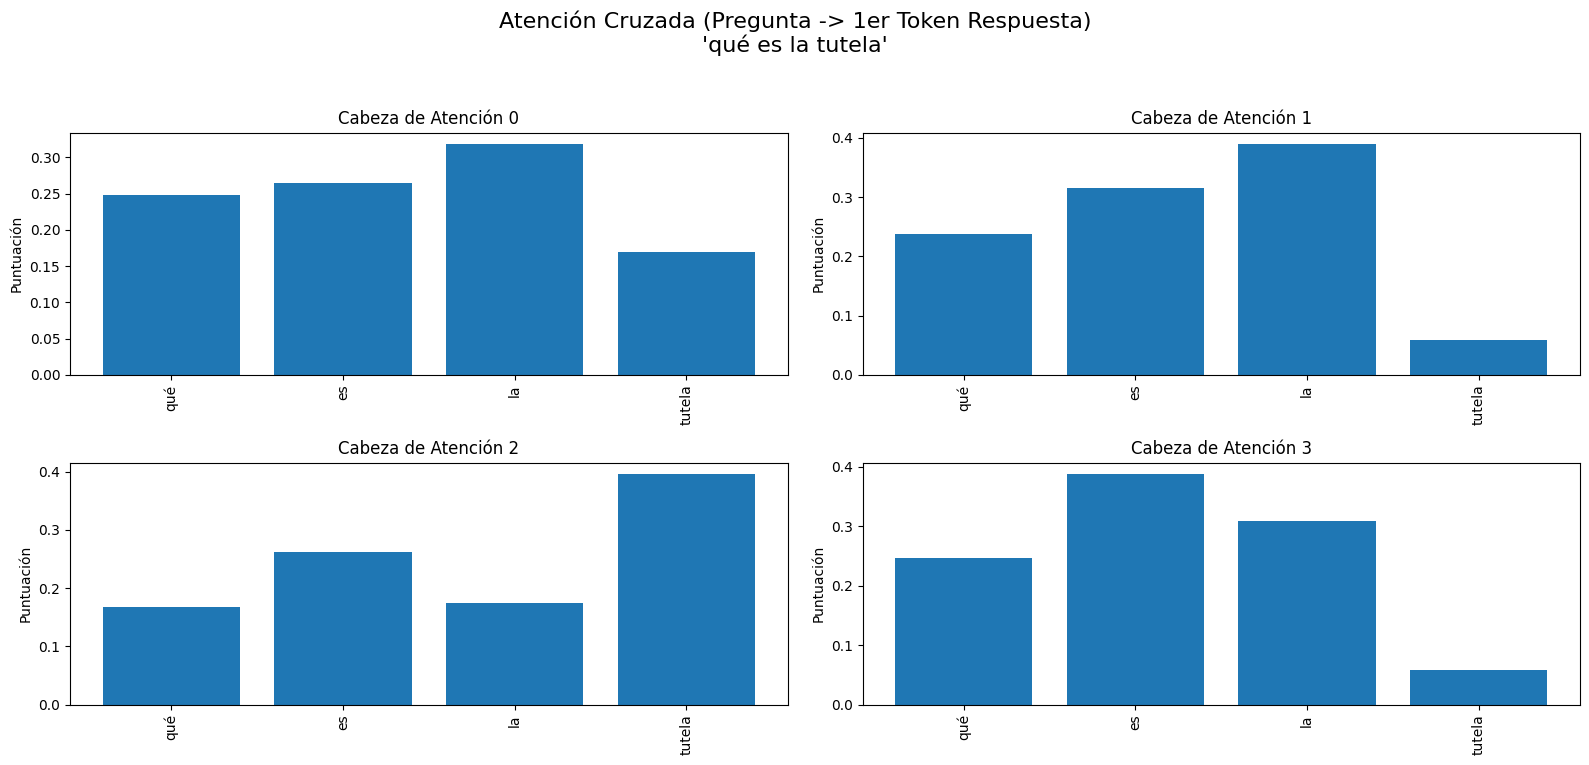

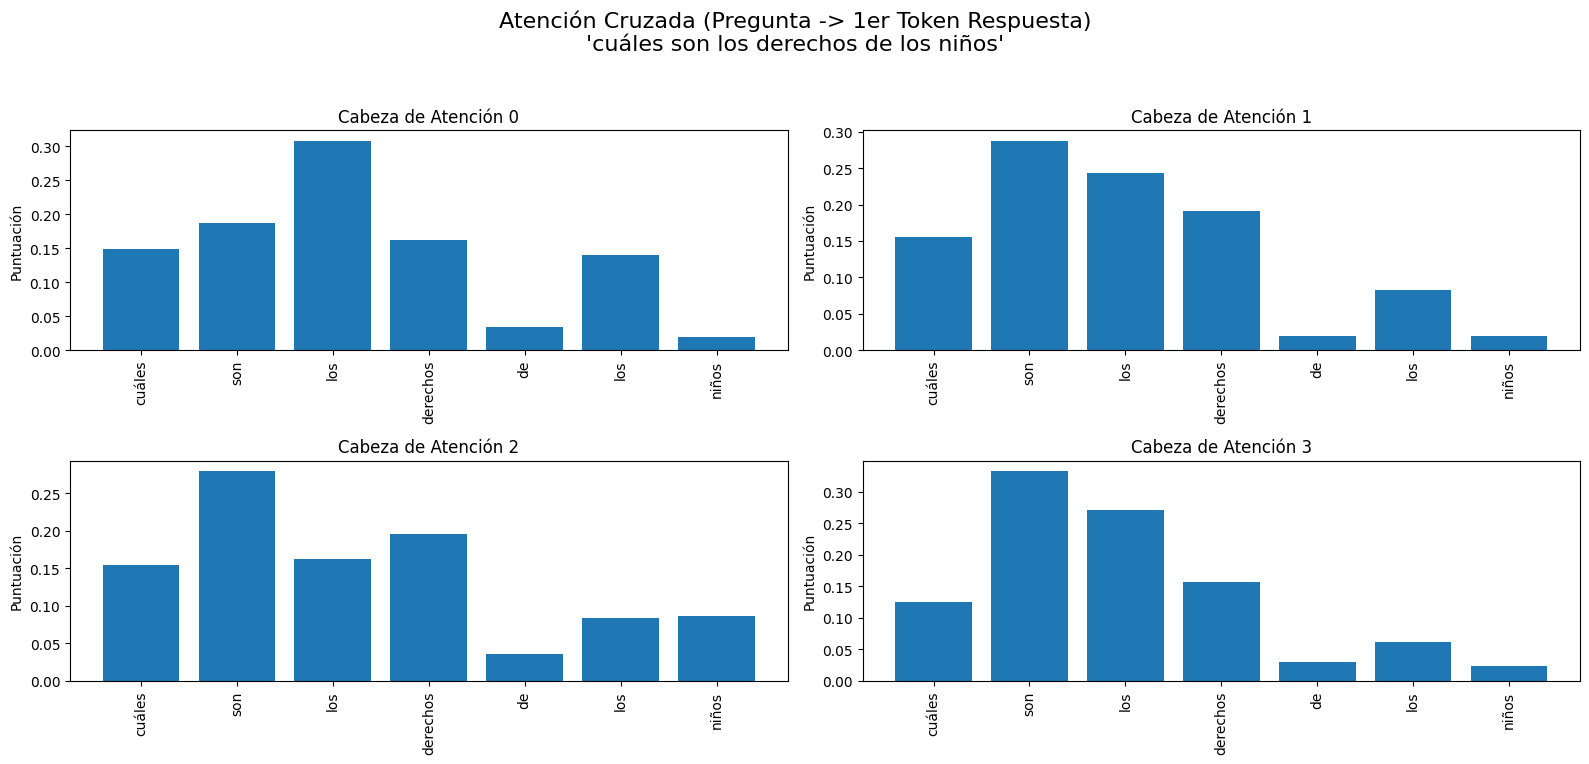

In [48]:
# ============================================================
# SOLUCIÓN ELEGANTE PARA LA VISUALIZACIÓN DE ATENCIÓN
# No se necesitan clases 'ForViz' ni cargar pesos.
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Paso 1: Modificar las clases originales para que puedan devolver atención ---

# Modificamos DecoderLayer
class DecoderLayer(layers.Layer): # Asegúrate de que esta es tu clase original
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha1 = MultiHeadAttention(d_model, num_heads)
        self.mha2 = MultiHeadAttention(d_model, num_heads)
        self.ffn = point_wise_feed_forward_network(d_model, d_ff)
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)
        self.dropout3 = layers.Dropout(dropout_rate)

    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        attn1, _ = self.mha1(x, x, x, look_ahead_mask)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(x + attn1)

        # El cambio clave: capturamos los pesos de atención de la segunda MHA
        attn2, attention_weights = self.mha2(out1, enc_output, enc_output, padding_mask)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(out1 + attn2)

        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.layernorm3(out2 + ffn_output)

        # Devolvemos la salida Y los pesos de atención
        return out3, attention_weights

# Modificamos Decoder
class Decoder(layers.Layer): # Asegúrate de que esta es tu clase original
    # ... (el __init__ es el mismo) ...
    def __init__(self, vocab_size, seq_len, num_layers, d_model, num_heads, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.seq_len = seq_len # Store seq_len
        self.num_layers = num_layers
        self.vocab_size = vocab_size # Store vocab_size
        self.num_heads = num_heads # Store num_heads
        self.d_ff = d_ff # Store d_ff
        self.dropout_rate = dropout_rate # Store dropout_rate

        self.embedding = layers.Embedding(vocab_size, d_model)
        self.dropout = layers.Dropout(dropout_rate)
        self.pos_encoding = positional_encoding(seq_len, d_model)
        # La lista de capas ahora usa nuestra DecoderLayer modificada
        self.dec_layers = [DecoderLayer(d_model, num_heads, d_ff, dropout_rate) for _ in range(num_layers)]

    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        seq_len = tf.shape(x)[1]
        attention_weights = {} # Un diccionario para guardar la atención de cada capa

        x = self.embedding(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:seq_len, :]
        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x, block_attention = self.dec_layers[i](
                x, enc_output,
                training=training,
                look_ahead_mask=look_ahead_mask,
                padding_mask=padding_mask
            )
            attention_weights[f'decoder_layer_{i+1}_attention'] = block_attention

        return x, attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({
            "vocab_size": self.vocab_size,
            "seq_len": self.seq_len,
            "num_layers": self.num_layers,
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "d_ff": self.d_ff,
            "dropout_rate": self.dropout_rate,
        })
        return config

# Modificamos Transformer
class Transformer(tf.keras.Model): # Asegúrate de que esta es tu clase original
    # ... (el __init__ es el mismo) ...
    def __init__(self, enc_vocab_size, dec_vocab_size, enc_seq_len, dec_seq_len,
                 num_layers=2, d_model=128, num_heads=4, d_ff=256, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.enc_vocab_size = enc_vocab_size
        self.dec_vocab_size = dec_vocab_size
        self.enc_seq_len = enc_seq_len
        self.dec_seq_len = dec_seq_len
        self.num_layers = num_layers
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_ff = d_ff
        self.dropout_rate = dropout_rate

        self.encoder = Encoder(enc_vocab_size, enc_seq_len, num_layers, d_model, num_heads, d_ff, dropout_rate)
        self.decoder = Decoder(dec_vocab_size, dec_seq_len, num_layers, d_model, num_heads, d_ff, dropout_rate)
        self.final_layer = layers.Dense(dec_vocab_size)

    def call(self, inputs, training=False, return_attention=False):
        encoder_input, decoder_input = inputs
        enc_padding_mask = create_padding_mask(encoder_input)
        dec_look_ahead_mask = create_decoder_masks(decoder_input)
        dec_padding_mask = enc_padding_mask

        enc_output = self.encoder(encoder_input, training=training, mask=enc_padding_mask)
        dec_output, attention_weights = self.decoder(decoder_input, enc_output, training=training, look_ahead_mask=dec_look_ahead_mask, padding_mask=dec_padding_mask)

        logits = self.final_layer(dec_output)

        if return_attention:
            return logits, attention_weights
        else:
            return logits

    def get_config(self):
        config = super().get_config()
        config.update({
            "enc_vocab_size": self.enc_vocab_size,
            "dec_vocab_size": self.dec_vocab_size,
            "enc_seq_len": self.enc_seq_len,
            "dec_seq_len": self.dec_seq_len,
            "num_layers": self.num_layers,
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "d_ff": self.d_ff,
            "dropout_rate": self.dropout_rate,
        })
        return config

    @classmethod
    def from_config(cls, config):
        # Extract the arguments needed for the __init__ method
        enc_vocab_size = config.pop("enc_vocab_size")
        dec_vocab_size = config.pop("dec_vocab_size")
        enc_seq_len = config.pop("enc_seq_len")
        dec_seq_len = config.pop("dec_seq_len")
        num_layers = config.pop("num_layers")
        d_model = config.pop("d_model")
        num_heads = config.pop("num_heads")
        d_ff = config.pop("d_ff")
        dropout_rate = config.pop("dropout_rate")

        # The remaining items in 'config' are for the base Model class's __init__
        return cls(
            enc_vocab_size=enc_vocab_size,
            dec_vocab_size=dec_vocab_size,
            enc_seq_len=enc_seq_len,
            dec_seq_len=dec_seq_len,
            num_layers=num_layers,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout_rate=dropout_rate,
            **config
        )

# --- Re-instantiate and load weights for the global 'transformer' object ---
# This must happen after the class definitions are updated.
print("Re-instantiating 'transformer' with updated class definitions...")
transformer = Transformer(
    enc_vocab_size=len(enc_vocab),
    dec_vocab_size=len(dec_vocab),
    enc_seq_len=ENC_SEQ_LEN,
    dec_seq_len=DEC_SEQ_LEN,
    num_layers=NUM_LAYERS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    dropout_rate=DROPOUT
)

# Build the model by passing a dummy input to initialize its weights
sample_input, _ = next(iter(val_ds))
_ = transformer(sample_input)

# Load the previously saved weights
transformer.load_weights(model_export_path) # Use load_weights not set_weights for saved models
print("Trained weights loaded into the re-instantiated 'transformer' object.")

# --- Paso 2: Crear la función de visualización ---
def plot_attention_matrix(question):
    # Vectorizar la pregunta de entrada
    enc_in = encode_question(question)

    # Preparar el primer token del decoder (<start>)
    dec_in_ids = [start_id]
    dec_in = tf.constant([dec_in_ids + [0] * (DEC_SEQ_LEN - len(dec_in_ids))], dtype=tf.int32)

    # Llamar al modelo pidiendo los pesos de atención
    _, attention_weights = transformer((enc_in, dec_in), return_attention=True)

    # Extraemos la atención de la ÚLTIMA capa del decoder
    last_layer_attention = attention_weights[f'decoder_layer_{NUM_LAYERS}_attention']

    # Obtenemos los tokens de la pregunta para los ejes del gráfico
    input_tokens = [enc_vocab[i] for i in enc_in.numpy()[0] if i != 0]

    # Crear la figura
    fig = plt.figure(figsize=(16, 8))
    plt.suptitle(f"Atención Cruzada (Pregunta -> 1er Token Respuesta)\n'{question}'", fontsize=16)

    # Iteramos sobre cada cabeza de atención
    for h in range(NUM_HEADS):
        ax = fig.add_subplot(2, (NUM_HEADS + 1) // 2, h + 1)

        # Extraemos la atención para esta cabeza en el primer paso de decodificación
        attention_head = last_layer_attention[0, h, 0, :len(input_tokens)].numpy()

        # Usamos un bar plot que es más claro para una sola fila
        ax.bar(range(len(input_tokens)), attention_head)
        ax.set_xticks(range(len(input_tokens))) # Set x-ticks first
        ax.set_xticklabels(input_tokens, rotation=90, fontsize=10) # Then set labels
        ax.set_title(f"Cabeza de Atención {h}")
        ax.set_ylabel("Puntuación")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# --- Paso 3: Ejecutar la visualización ---
print("Generando gráficos de atención...")
plot_attention_matrix("qué es la tutela")
plot_attention_matrix("cuáles son los derechos de los niños")

In [44]:
# ============================================================
# SECCIÓN 11.1: EXPORTAR EL MODELO A FORMATO SavedModel
# ============================================================
# Una vez entrenado, podemos guardar el modelo para cargarlo más tarde
# sin necesidad de tener el código de entrenamiento.
#
# Le daremos un nombre al directorio donde se guardará.
# ============================================================

# Definimos el nombre del directorio para nuestro modelo guardado.
model_export_path = "transformer_model.keras"

# Usamos el método .save() del modelo.
# Esto creará un directorio con todos los archivos necesarios.
transformer.save(model_export_path)

print(f"Modelo exportado exitosamente en el directorio: '{model_export_path}'")

# Si estás en Google Colab, puedes listar los archivos para ver el directorio creado.
!ls -l

Modelo exportado exitosamente en el directorio: 'transformer_model.keras'
total 11860
-rw-r--r-- 1 root root    50533 Feb 26 22:29 entrenamiento_constitucion.txt
drwxr-xr-x 1 root root     4096 Jan 16 14:24 sample_data
-rw-r--r-- 1 root root 12085665 Feb 26 22:57 transformer_model.keras
